Nasa Group Profect by Felix Ting and Manav Choudhary

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import re

time = []
rv = []
rv_err = []

with open("55Cnc_RV.txt", "r") as f:
    for line in f:
        line = line.strip()
        
        if not line:
            continue
        
        if line.startswith("\\"):
            continue
        
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", line)
        
        if len(nums) >= 3:
            time.append(float(nums[0]))
            rv.append(float(nums[1]))
            rv_err.append(float(nums[2]))

time = np.array(time)
rv = np.array(rv)
rv_err = np.array(rv_err)

print("Loaded data points:", len(time))
print(time[:5])
print(rv[:5])
print(rv_err[:5])

Loaded data points: 274
[2449676.0632  2449767.77441 2449768.83203 2449793.79785 2450056.98828]
[131.91000366  22.60000038  -5.48999977 107.30999756 116.66999817]
[4.8400002 2.5699999 2.6800001 1.52      1.6199999]


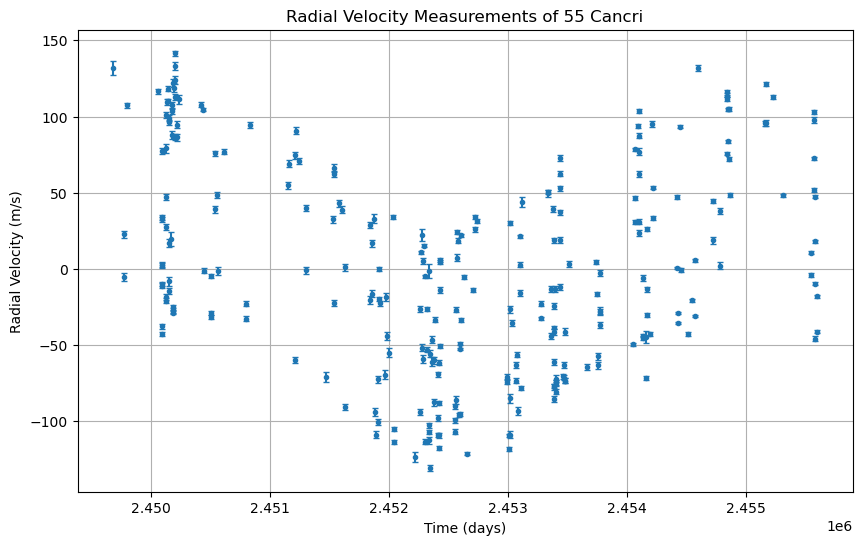

In [3]:
plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, capsize=2)

plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("Radial Velocity Measurements of 55 Cancri")
plt.grid(True)
plt.show()

The radial velocity signal is modeled with a sinusoidal function, since an orbiting exoplanet causes the star to move back and forth in a repeating pattern. We use `scipy.optimize.curve_fit` to determine the best-fit amplitude, period, phase, and vertical offset.

Best-fit amplitude K = 16.20568171590976
Best-fit period P = 14.002274538633952
Best-fit phase = 178.2863649368378
Best-fit offset = 0.2915705684881132


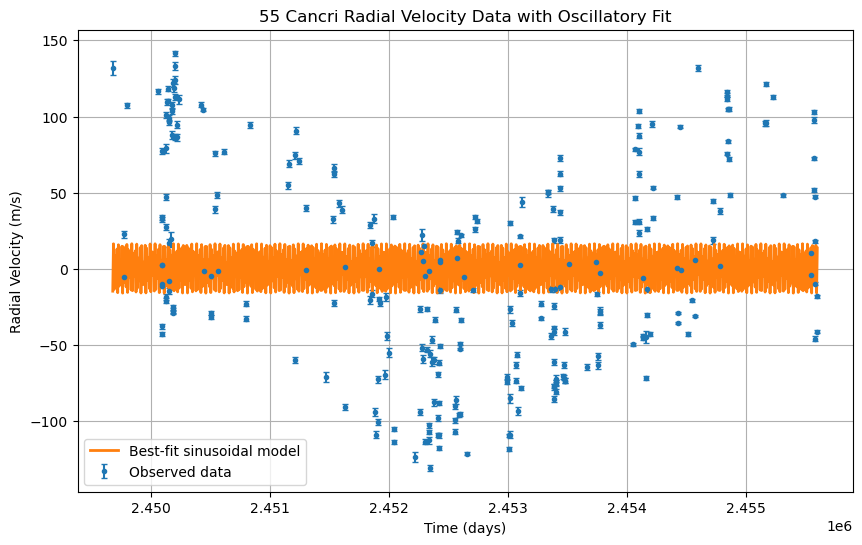

In [4]:
from scipy.optimize import curve_fit

def rv_model(t, K, P, phi, C):
    return K * np.sin(2*np.pi*t/P + phi) + C

initial_guesses = [15, 14, 0, 0]

params, covariance = curve_fit(
    rv_model,
    time,
    rv,
    sigma=rv_err,
    p0=initial_guesses,
    absolute_sigma=True,
    maxfev=10000
)

K_fit, P_fit, phi_fit, C_fit = params

print("Best-fit amplitude K =", K_fit)
print("Best-fit period P =", P_fit)
print("Best-fit phase =", phi_fit)
print("Best-fit offset =", C_fit)

t_model = np.linspace(time.min(), time.max(), 1000)
rv_fit = rv_model(t_model, K_fit, P_fit, phi_fit, C_fit)

plt.figure(figsize=(10,6))
plt.errorbar(time, rv, yerr=rv_err, fmt='o', markersize=3, capsize=2, label="Observed data")
plt.plot(t_model, rv_fit, linewidth=2, label="Best-fit sinusoidal model")

plt.xlabel("Time (days)")
plt.ylabel("Radial Velocity (m/s)")
plt.title("55 Cancri Radial Velocity Data with Oscillatory Fit")
plt.legend()
plt.grid(True)
plt.show()

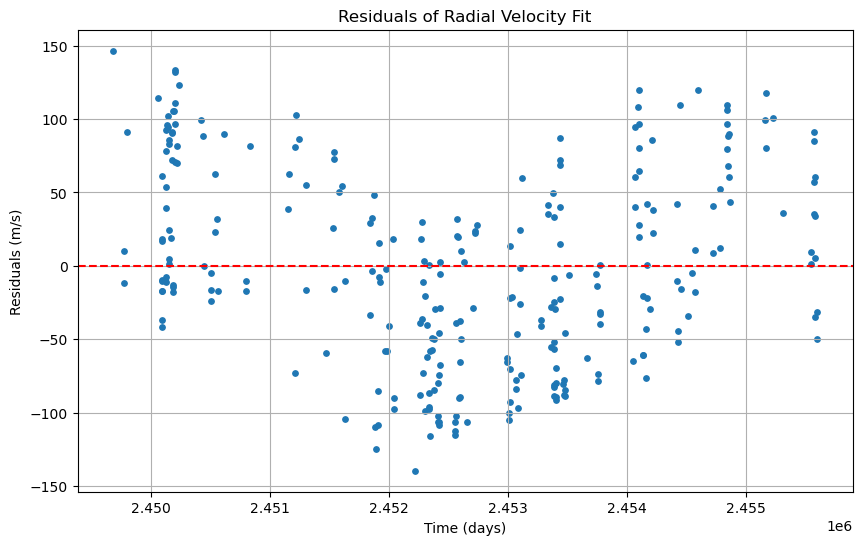

In [5]:
rv_model_data = rv_model(time, K_fit, P_fit, phi_fit, C_fit)
residuals = rv - rv_model_data

plt.figure(figsize=(10,6))

plt.scatter(time, residuals, s=15)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Time (days)")
plt.ylabel("Residuals (m/s)")
plt.title("Residuals of Radial Velocity Fit")

plt.grid(True)

plt.show()

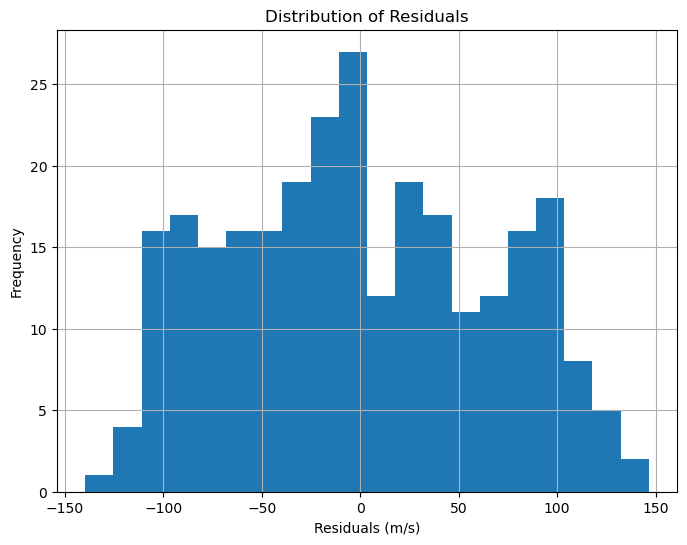

In [6]:
plt.figure(figsize=(8,6))

plt.hist(residuals, bins=20)

plt.xlabel("Residuals (m/s)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.grid(True)

plt.show()

In [7]:
std_residuals = np.std(residuals)

print("Standard deviation of residuals =", std_residuals)

Standard deviation of residuals = 66.09789271702081


Residuals were calculated by subtracting the best-fit sinusoidal model from the measured radial velocity data. If the model fully explains the observed signal, the residuals should be randomly distributed around zero. A histogram of the residuals was generated to examine their distribution. The standard deviation of the residuals was compared to the experimental uncertainty of the measurements to assess the quality of the model fit.

The mass of the detected exoplanet was calculated using the amplitude and period obtained from the sinusoidal fit of the radial velocity data. The mass of the host star 55 Cancri was taken to be 0.905 solar masses. Using the provided formula, the estimated mass of the exoplanet was obtained in units of Jupiter masses. The period obtained from the fit was compared with values listed in the NASA Exoplanet Archive to identify the planet.